<a href="https://colab.research.google.com/github/Nikita1532001/real-time-project/blob/main/ipl_match.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🏏 IPL Match Prediction — Complete ML Project
### Predict IPL match winners using Machine Learning

**Models covered:** Logistic Regression · Random Forest · Gradient Boosting · XGBoost  
**Dataset:** [Kaggle IPL Complete Dataset 2008–2020](https://www.kaggle.com/datasets/patrickb1912/ipl-complete-dataset-20082020)


In [1]:
## 1. Install Dependencies
!pip install pandas numpy scikit-learn xgboost shap matplotlib seaborn --quiet


## 2. Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import warnings
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("✅ XGBoost available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost not installed — skipping")

try:
    import shap
    SHAP_AVAILABLE = True
    print("✅ SHAP available")
except ImportError:
    SHAP_AVAILABLE = False
    print("⚠️  SHAP not installed — skipping")

warnings.filterwarnings("ignore")
np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")

# ── CONFIG ──
MATCHES_CSV  = "matches.csv"      # ← point to your Kaggle CSV
TEST_SIZE    = 0.2
RANDOM_STATE = 42
CV_FOLDS     = 5

print("\n✅ All imports successful")


✅ XGBoost available
✅ SHAP available

✅ All imports successful


## 3. Data Loading

In [3]:
def generate_synthetic_data(n=800):
    """Synthetic IPL dataset for demo when real CSV is absent."""
    teams = [
        "Mumbai Indians", "Chennai Super Kings",
        "Royal Challengers Bangalore", "Kolkata Knight Riders",
        "Delhi Capitals", "Rajasthan Royals",
        "Sunrisers Hyderabad", "Punjab Kings",
        "Lucknow Super Giants", "Gujarat Titans",
    ]
    venues = [
        "Wankhede Stadium", "M Chinnaswamy Stadium",
        "Eden Gardens", "MA Chidambaram Stadium",
        "Narendra Modi Stadium", "Arun Jaitley Stadium",
    ]
    rng = np.random.default_rng(42)
    records = []
    for i in range(n):
        t1, t2 = rng.choice(teams, 2, replace=False)
        venue   = rng.choice(venues)
        season  = int(rng.choice(range(2008, 2025)))
        toss_w  = rng.choice([t1, t2])
        toss_d  = rng.choice(["bat", "field"])
        p_t1    = 0.52 if (toss_w == t1 and toss_d == "field") else 0.48
        winner  = t1 if rng.random() < p_t1 else t2
        records.append({
            "id": i+1, "season": season,
            "date": f"{season}-04-{rng.integers(1,30):02d}",
            "team1": t1, "team2": t2,
            "toss_winner": toss_w, "toss_decision": toss_d,
            "result": "normal", "dl_applied": 0, "winner": winner,
            "win_by_runs": int(rng.integers(0,80)) if winner==t1 else 0,
            "win_by_wickets": int(rng.integers(0,10)) if winner==t2 else 0,
            "venue": venue,
        })
    return pd.DataFrame(records)


def load_data(path):
    if os.path.exists(path):
        print(f"📂 Loading real dataset: {path}")
        df = pd.read_csv(path)
    else:
        print("⚠️  matches.csv not found — using synthetic dataset")
        df = generate_synthetic_data()

    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
    df = df.dropna(subset=["winner"]).copy()
    if "result" in df.columns:
        df = df[~df["result"].isin(["no result", "tie"])].copy()
    print(f"✅ Dataset shape: {df.shape}")
    return df


df = load_data(MATCHES_CSV)
df.head()


⚠️  matches.csv not found — using synthetic dataset
✅ Dataset shape: (800, 13)


,id,season,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,venue
0,1,2015,2015-04-21,Mumbai Indians,Punjab Kings,Punjab Kings,bat,normal,0,Mumbai Indians,42,0,Eden Gardens
1,2,2021,2021-04-15,Lucknow Super Giants,Punjab Kings,Punjab Kings,bat,normal,0,Lucknow Super Giants,29,0,Narendra Modi Stadium
2,3,2014,2014-04-13,Chennai Super Kings,Gujarat Titans,Gujarat Titans,field,normal,0,Chennai Super Kings,7,0,MA Chidambaram Stadium
3,4,2022,2022-04-21,Lucknow Super Giants,Delhi Capitals,Lucknow Super Giants,field,normal,0,Delhi Capitals,0,3,Arun Jaitley Stadium
4,5,2019,2019-04-06,Gujarat Titans,Mumbai Indians,Mumbai Indians,field,normal,0,Gujarat Titans,39,0,Arun Jaitley Stadium


In [5]:
### 4. Exploratory Data Analysis (EDA)


In [6]:
print("Dataset Info")
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum())


Dataset Info
id                 int64
season             int64
date              object
team1             object
team2             object
toss_winner       object
toss_decision     object
result            object
dl_applied         int64
winner            object
win_by_runs        int64
win_by_wickets     int64
venue             object
dtype: object

Missing values:
 id                0
season            0
date              0
team1             0
team2             0
toss_winner       0
toss_decision     0
result            0
dl_applied        0
winner            0
win_by_runs       0
win_by_wickets    0
venue             0
dtype: int64


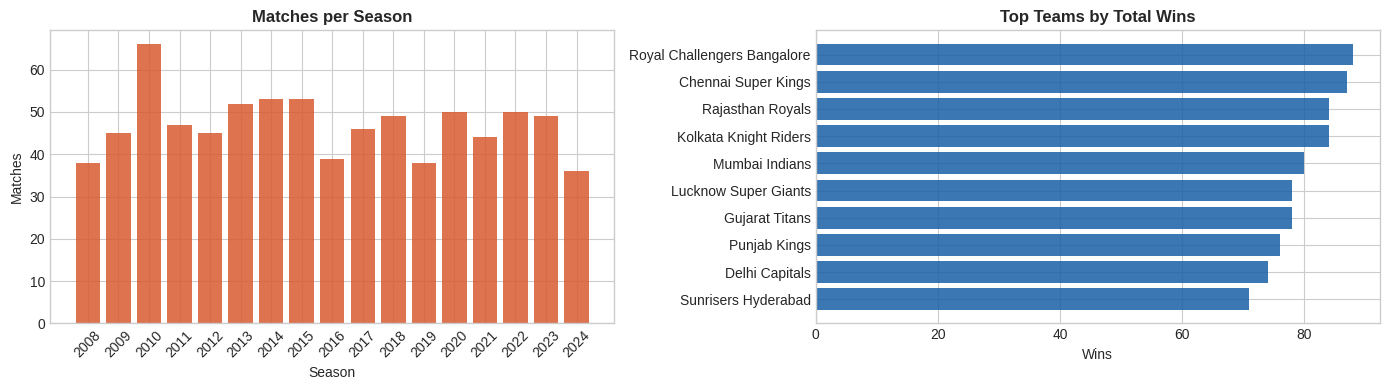

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

season_counts = df["season"].value_counts().sort_index()
axes[0].bar(season_counts.index.astype(str), season_counts.values, color="#D85A30", alpha=0.85)
axes[0].set_title("Matches per Season", fontweight="bold")
axes[0].set_xlabel("Season"); axes[0].set_ylabel("Matches")
axes[0].tick_params(axis="x", rotation=45)

# Top teams by wins
all_wins = df["winner"].value_counts().head(10)
axes[1].barh(all_wins.index[::-1], all_wins.values[::-1], color="#185FA5", alpha=0.85)
axes[1].set_title("Top Teams by Total Wins", fontweight="bold")
axes[1].set_xlabel("Wins")

plt.tight_layout()
plt.show()

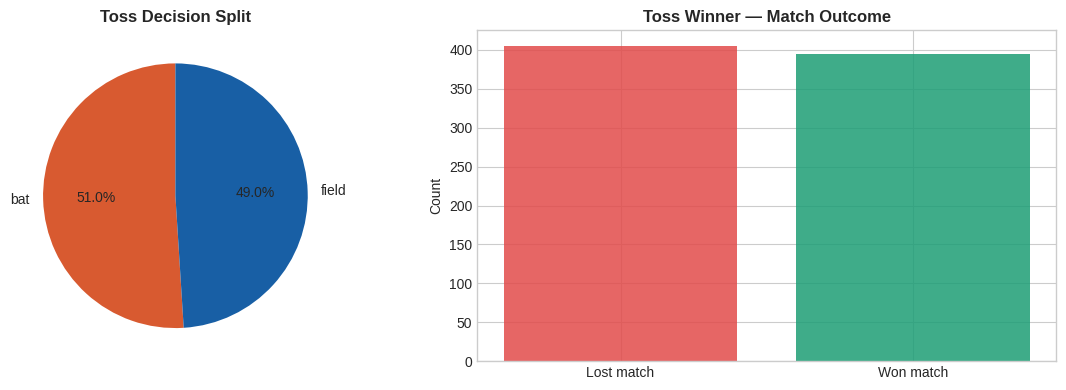

Toss winner wins the match 50.6% of the time


In [8]:
# Toss decision distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

toss_dec = df["toss_decision"].value_counts()
axes[0].pie(toss_dec, labels=toss_dec.index, autopct="%1.1f%%",
            colors=["#D85A30","#185FA5"], startangle=90)
axes[0].set_title("Toss Decision Split", fontweight="bold")

# Does toss winner win the match?
df["toss_winner_won"] = (df["toss_winner"] == df["winner"]).astype(int)
tw_win = df["toss_winner_won"].value_counts()
axes[1].bar(["Lost match","Won match"], tw_win.values, color=["#E24B4A","#1D9E75"], alpha=0.85)
axes[1].set_title("Toss Winner — Match Outcome", fontweight="bold")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

toss_win_rate = df["toss_winner_won"].mean()
print(f"Toss winner wins the match {toss_win_rate:.1%} of the time")


## 5. Feature Engineering

In [10]:
class IPLFeatureEngineer:
    def __init__(self):
        self.le_team  = LabelEncoder()
        self.le_venue = LabelEncoder()
        self._fitted  = False

    def fit_transform(self, df):
        df = df.copy().reset_index(drop=True)
        if "id" not in df.columns:
            df["id"] = df.index
        df = df.sort_values(["season", "id"]).reset_index(drop=True)

        df["target"]   = (df["winner"] == df["team1"]).astype(int)
        df["toss_win"] = (df["toss_winner"] == df["team1"]).astype(int)
        df["toss_bat"] = (df["toss_decision"] == "bat").astype(int)

        df = self._add_historical_features(df)

        all_teams = pd.concat([df["team1"], df["team2"]]).unique()
        self.le_team.fit(all_teams)
        self.le_venue.fit(df["venue"].unique())

        df["team1_enc"] = self.le_team.transform(df["team1"])
        df["team2_enc"] = self.le_team.transform(df["team2"])
        df["venue_enc"] = self.le_venue.transform(df["venue"])

        self._fitted = True
        return df

    def _add_historical_features(self, df):
        wins, h2h, venue_w, form = {}, {}, {}, {}
        t1wp, t2wp, h2hwp, t1f, t2f, vt1, vt2 = [], [], [], [], [], [], []

        for _, row in df.iterrows():
            t1, t2, venue, winner = row["team1"], row["team2"], row["venue"], row["winner"]
            w1 = wins.get(t1, [0,0]); w2 = wins.get(t2, [0,0])
            t1wp.append(w1[0]/w1[1] if w1[1]>0 else 0.5)
            t2wp.append(w2[0]/w2[1] if w2[1]>0 else 0.5)

            key = tuple(sorted([t1,t2]))
            h = h2h.get(key,[0,0])
            h2hwp.append(h[0]/h[1] if h[1]>0 else 0.5)

            f1 = form.get(t1,[]); f2 = form.get(t2,[])
            t1f.append(np.mean(f1[-5:]) if f1 else 0.5)
            t2f.append(np.mean(f2[-5:]) if f2 else 0.5)

            vk1,vk2 = (t1,venue),(t2,venue)
            vw1=venue_w.get(vk1,[0,0]); vw2=venue_w.get(vk2,[0,0])
            vt1.append(vw1[0]/vw1[1] if vw1[1]>0 else 0.5)
            vt2.append(vw2[0]/vw2[1] if vw2[1]>0 else 0.5)

            t1_won = int(winner==t1)
            wins[t1]=[wins.get(t1,[0,0])[0]+t1_won, wins.get(t1,[0,0])[1]+1]
            wins[t2]=[wins.get(t2,[0,0])[0]+(1-t1_won), wins.get(t2,[0,0])[1]+1]
            h2h[key]=[h[0]+(1 if winner==key[0] else 0), h[1]+1]
            form.setdefault(t1,[]).append(t1_won)
            form.setdefault(t2,[]).append(1-t1_won)
            venue_w[vk1]=[venue_w.get(vk1,[0,0])[0]+t1_won, venue_w.get(vk1,[0,0])[1]+1]
            venue_w[vk2]=[venue_w.get(vk2,[0,0])[0]+(1-t1_won), venue_w.get(vk2,[0,0])[1]+1]

        df["team1_win_pct"]=t1wp; df["team2_win_pct"]=t2wp
        df["h2h_t1_win_pct"]=h2hwp
        df["team1_form"]=t1f; df["team2_form"]=t2f
        df["venue_t1_win_pct"]=vt1; df["venue_t2_win_pct"]=vt2
        return df


fe = IPLFeatureEngineer()
df_feat = fe.fit_transform(df)

FEATURE_COLS = [
    "toss_win","toss_bat",
    "team1_win_pct","team2_win_pct","h2h_t1_win_pct",
    "team1_form","team2_form",
    "venue_t1_win_pct","venue_t2_win_pct",
    "team1_enc","team2_enc","venue_enc",
]

X = df_feat[FEATURE_COLS]
y = df_feat["target"]

print(f"Feature matrix : {X.shape}")
print(f"Class balance  — Team1 wins: {y.mean():.2%}  |  Team2 wins: {1-y.mean():.2%}")
df_feat[FEATURE_COLS + ["target"]].head()







Feature matrix : (800, 12)
Class balance  — Team1 wins: 49.88%  |  Team2 wins: 50.12%


,toss_win,toss_bat,team1_win_pct,team2_win_pct,h2h_t1_win_pct,team1_form,team2_form,venue_t1_win_pct,venue_t2_win_pct,team1_enc,team2_enc,venue_enc,target
0,0,0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,4,0,4,0
1,1,1,0.5,0.5,0.5,0.5,0.5,0.5,0.5,3,6,1,0
2,0,1,0.5,0.5,0.5,0.5,0.5,0.5,0.5,1,9,0,0
3,1,1,0.5,1.0,0.5,0.5,1.0,0.5,1.0,5,9,0,1
4,1,1,0.0,1.0,0.5,0.0,1.0,0.5,1.0,4,6,1,0



## 6. Train / Test Split

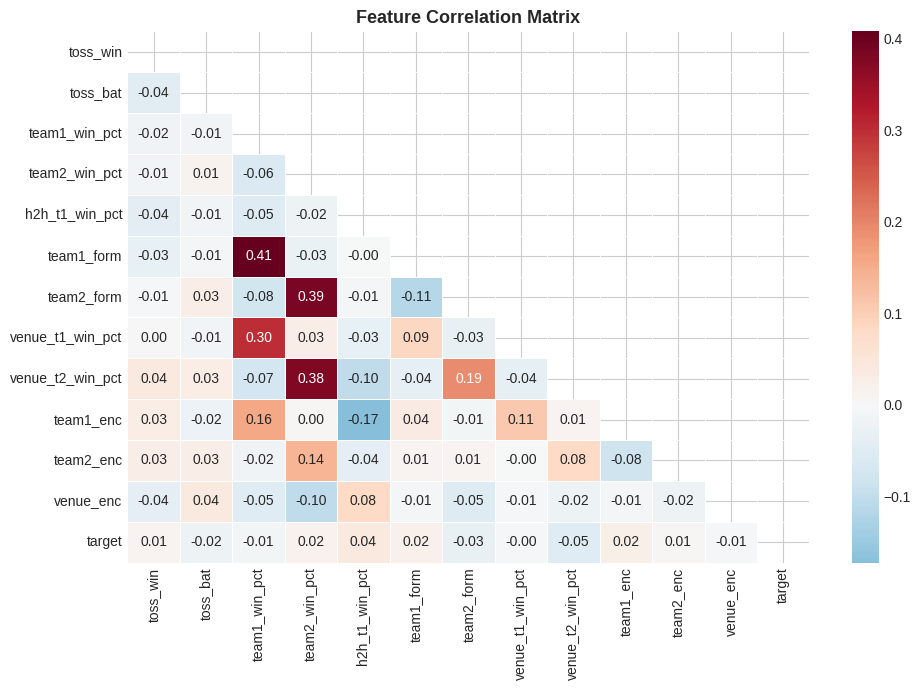

Train samples : 640
Test  samples : 160


In [11]:
### Feature Correlation Heatmap


fig, ax = plt.subplots(figsize=(10, 7))
corr = df_feat[FEATURE_COLS + ["target"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Feature Correlation Matrix", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Train samples : {len(X_train)}")
print(f"Test  samples : {len(X_test)}")



 7. Model Training & Evaluation

In [12]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:,1]
    acc  = accuracy_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_proba)
    cv   = cross_val_score(model, X_tr, y_tr, cv=CV_FOLDS, scoring="accuracy").mean()
    print(f"\n{'─'*45}  {name}")
    print(f"  Test Accuracy : {acc:.4f}  |  ROC-AUC : {auc:.4f}  |  CV Acc : {cv:.4f}")
    print(classification_report(y_te, y_pred, target_names=["Team2 wins","Team1 wins"]))
    return {"name": name, "model": model, "acc": acc, "auc": auc, "cv": cv,
            "y_pred": y_pred, "y_proba": y_proba}

models_dict = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=8,
                                                  random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                      max_depth=5, random_state=RANDOM_STATE),
}
if XGBOOST_AVAILABLE:
    models_dict["XGBoost"] = XGBClassifier(n_estimators=200, learning_rate=0.05,
                                            max_depth=6, use_label_encoder=False,
                                            eval_metric="logloss", random_state=RANDOM_STATE)

results = []
for name, model in models_dict.items():
    res = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    results.append(res)



─────────────────────────────────────────────  Logistic Regression
  Test Accuracy : 0.4250  |  ROC-AUC : 0.4091  |  CV Acc : 0.4734
              precision    recall  f1-score   support

  Team2 wins       0.43      0.45      0.44        80
  Team1 wins       0.42      0.40      0.41        80

    accuracy                           0.42       160
   macro avg       0.42      0.43      0.42       160
weighted avg       0.42      0.42      0.42       160


─────────────────────────────────────────────  Random Forest
  Test Accuracy : 0.5188  |  ROC-AUC : 0.5256  |  CV Acc : 0.5031
              precision    recall  f1-score   support

  Team2 wins       0.52      0.55      0.53        80
  Team1 wins       0.52      0.49      0.50        80

    accuracy                           0.52       160
   macro avg       0.52      0.52      0.52       160
weighted avg       0.52      0.52      0.52       160


─────────────────────────────────────────────  Gradient Boosting
  Test Accuracy : 

## 8. Hyperparameter Tuning (Random Forest)

In [13]:
param_grid = {
    "n_estimators":      [100, 200],
    "max_depth":         [6, 8, 10],
    "min_samples_split": [2, 5],
}
cv_strat = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
gs = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid, cv=cv_strat, scoring="accuracy", verbose=1, n_jobs=-1
)
gs.fit(X_train, y_train)

print(f"\n✅ Best params : {gs.best_params_}")
print(f"   CV Accuracy : {gs.best_score_:.4f}")

best_rf_res = evaluate_model("Random Forest (tuned)", gs.best_estimator_,
                              X_train, X_test, y_train, y_test)
results.append(best_rf_res)

Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Best params : {'max_depth': 6, 'min_samples_split': 2, 'n_estimators': 200}
   CV Accuracy : 0.5453

─────────────────────────────────────────────  Random Forest (tuned)
  Test Accuracy : 0.5188  |  ROC-AUC : 0.4933  |  CV Acc : 0.5109
              precision    recall  f1-score   support

  Team2 wins       0.52      0.55      0.53        80
  Team1 wins       0.52      0.49      0.50        80

    accuracy                           0.52       160
   macro avg       0.52      0.52      0.52       160
weighted avg       0.52      0.52      0.52       160



## 9. Model Comparison Plots

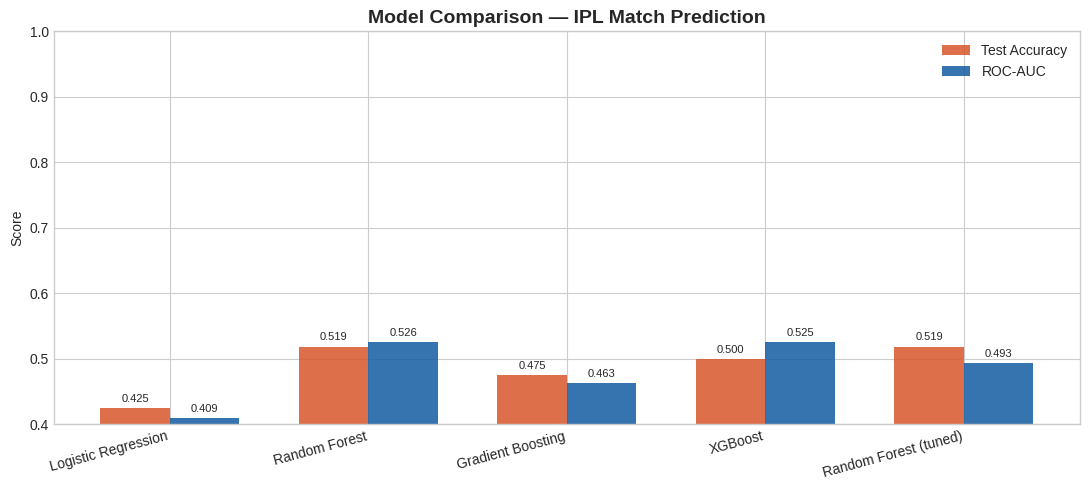

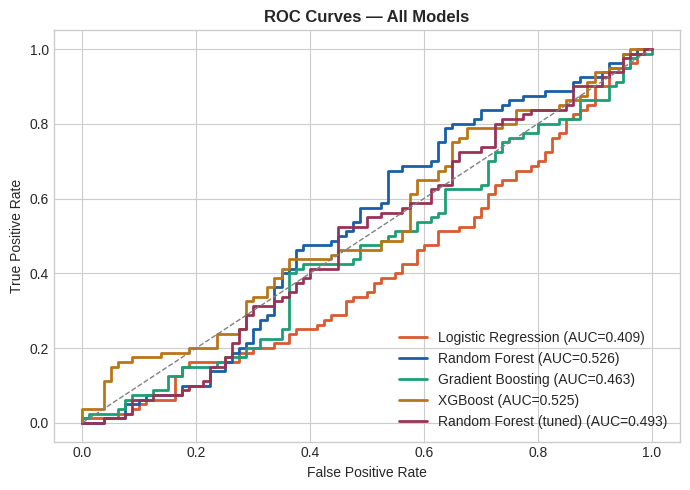

Best model: Random Forest  (AUC=0.5256)


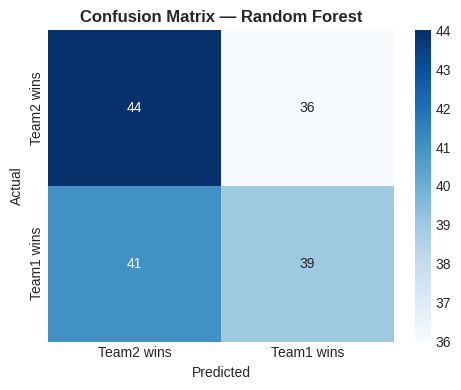

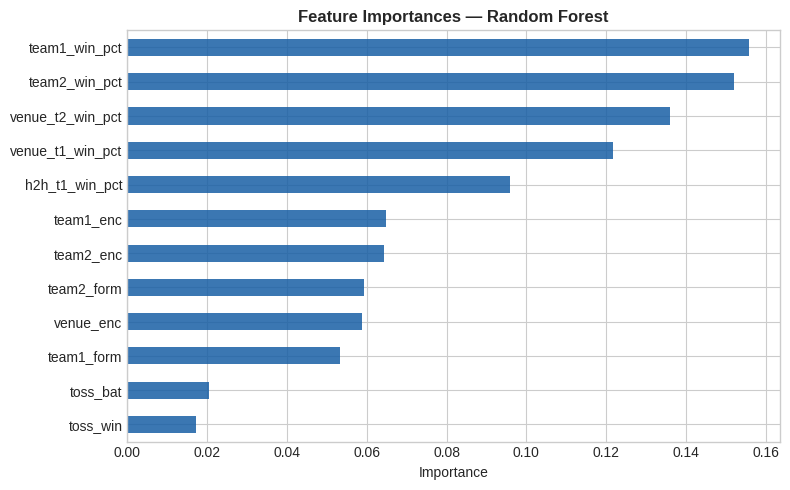

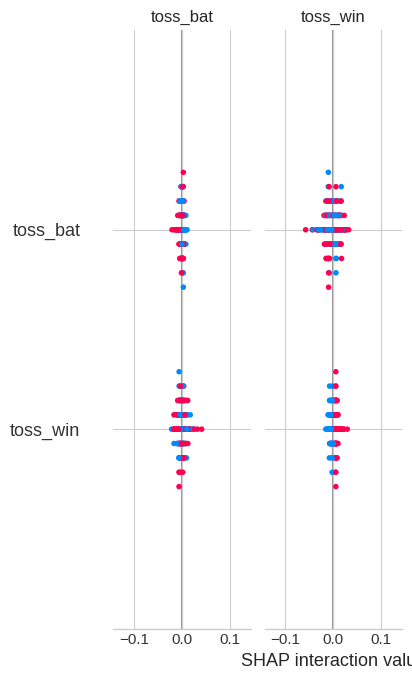

In [14]:

# Bar chart — Accuracy vs AUC
names = [r["name"] for r in results]
accs  = [r["acc"]  for r in results]
aucs  = [r["auc"]  for r in results]
x = np.arange(len(names)); w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x-w/2, accs, w, label="Test Accuracy", color="#D85A30", alpha=0.87)
b2 = ax.bar(x+w/2, aucs, w, label="ROC-AUC",       color="#185FA5", alpha=0.87)
ax.set_ylim(0.4, 1.0)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha="right")
ax.set_title("Model Comparison — IPL Match Prediction", fontsize=14, fontweight="bold")
ax.set_ylabel("Score"); ax.legend()
ax.bar_label(b1, fmt="%.3f", padding=3, fontsize=8)
ax.bar_label(b2, fmt="%.3f", padding=3, fontsize=8)
plt.tight_layout(); plt.show()



# ROC curves
fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#D85A30","#185FA5","#1D9E75","#BA7517","#993356"]
for i, r in enumerate(results):
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    ax.plot(fpr, tpr, label=f"{r['name']} (AUC={r['auc']:.3f})",
            color=colors[i % len(colors)], lw=2)
ax.plot([0,1],[0,1],"--", color="gray", lw=1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()



# Confusion matrix for best model
best = max(results, key=lambda r: r["auc"])
print(f"Best model: {best['name']}  (AUC={best['auc']:.4f})")

cm = confusion_matrix(y_test, best["y_pred"])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Team2 wins","Team1 wins"],
            yticklabels=["Team2 wins","Team1 wins"])
ax.set_title(f"Confusion Matrix — {best['name']}", fontweight="bold")
ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
plt.tight_layout(); plt.show()


# Feature importance
best_model = best["model"]
if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values()
    fig, ax = plt.subplots(figsize=(8, 5))
    imp.plot(kind="barh", ax=ax, color="#185FA5", alpha=0.85)
    ax.set_title(f"Feature Importances — {best['name']}", fontweight="bold")
    ax.set_xlabel("Importance")
    plt.tight_layout(); plt.show()



# SHAP summary plot
if SHAP_AVAILABLE and hasattr(best_model, "feature_importances_"):
    explainer  = shap.TreeExplainer(best_model)
    X_test_df  = pd.DataFrame(X_test.values, columns=FEATURE_COLS)
    shap_vals  = explainer.shap_values(X_test_df)
    vals = shap_vals[1] if isinstance(shap_vals, list) else shap_vals
    shap.summary_plot(vals, X_test_df, show=True)
else:
    print("SHAP not available or model does not support tree explainer.")

## 10. Predict a New Match

In [15]:
 # Use `predict_match()` to forecast the winner of any upcoming fixture.



def predict_match(
    model, fe,
    team1, team2, venue,
    toss_winner, toss_decision,
    team1_win_pct=0.5, team2_win_pct=0.5,
    h2h_t1_win_pct=0.5,
    team1_form=0.5, team2_form=0.5,
    venue_t1_win_pct=0.5, venue_t2_win_pct=0.5,
):
    try:
        t1_enc = fe.le_team.transform([team1])[0]
        t2_enc = fe.le_team.transform([team2])[0]
        v_enc  = fe.le_venue.transform([venue])[0]
    except ValueError as e:
        raise ValueError(f"Unknown team/venue — must appear in training data.\n{e}")

    X_new = pd.DataFrame([{
        "toss_win":          int(toss_winner == team1),
        "toss_bat":          int(toss_decision == "bat"),
        "team1_win_pct":     team1_win_pct,
        "team2_win_pct":     team2_win_pct,
        "h2h_t1_win_pct":   h2h_t1_win_pct,
        "team1_form":        team1_form,
        "team2_form":        team2_form,
        "venue_t1_win_pct":  venue_t1_win_pct,
        "venue_t2_win_pct":  venue_t2_win_pct,
        "team1_enc":         t1_enc,
        "team2_enc":         t2_enc,
        "venue_enc":         v_enc,
    }])

    proba  = model.predict_proba(X_new)[0]
    winner = team1 if proba[1] >= 0.5 else team2
    conf   = max(proba) * 100

    return {
        "team1": team1, "team2": team2,
        "predicted_winner":  winner,
        "team1_win_prob":    round(proba[1]*100, 1),
        "team2_win_prob":    round(proba[0]*100, 1),
        "confidence":        round(conf, 1),
        "confidence_level":  "High" if conf>65 else "Moderate" if conf>55 else "Low",
    }

print("✅ predict_match() ready")



# ── Example predictions ──
matchups = [
    dict(team1="Mumbai Indians", team2="Chennai Super Kings",
         venue="Wankhede Stadium", toss_winner="Mumbai Indians", toss_decision="field",
         team1_win_pct=0.60, team2_win_pct=0.58, h2h_t1_win_pct=0.60,
         team1_form=0.80, team2_form=0.60, venue_t1_win_pct=0.65, venue_t2_win_pct=0.40),
    dict(team1="Royal Challengers Bangalore", team2="Kolkata Knight Riders",
         venue="M Chinnaswamy Stadium", toss_winner="Kolkata Knight Riders", toss_decision="bat",
         team1_win_pct=0.45, team2_win_pct=0.55, h2h_t1_win_pct=0.44,
         team1_form=0.60, team2_form=0.80, venue_t1_win_pct=0.50, venue_t2_win_pct=0.45),
    dict(team1="Rajasthan Royals", team2="Gujarat Titans",
         venue="Narendra Modi Stadium", toss_winner="Gujarat Titans", toss_decision="field",
         team1_win_pct=0.50, team2_win_pct=0.54, h2h_t1_win_pct=0.48,
         team1_form=0.60, team2_form=0.60, venue_t1_win_pct=0.45, venue_t2_win_pct=0.55),
]

print(f"{'─'*65}")
print(f"{'Match':<40}  {'Winner':<30}  {'Prob':>6}  {'Confidence'}")
print(f"{'─'*65}")
for m in matchups:
    pred = predict_match(best_model, fe, **m)
    match_str = f"{pred['team1'].split()[-1]} vs {pred['team2'].split()[-1]}"
    print(f"{match_str:<40}  {pred['predicted_winner']:<30}  "
          f"{pred['confidence']:>5.1f}%  {pred['confidence_level']}")

✅ predict_match() ready
─────────────────────────────────────────────────────────────────
Match                                     Winner                            Prob  Confidence
─────────────────────────────────────────────────────────────────
Indians vs Kings                          Mumbai Indians                   54.5%  Low
Bangalore vs Riders                       Royal Challengers Bangalore      68.5%  High
Royals vs Titans                          Rajasthan Royals                 61.3%  Moderate


## 11. Summary & Next Steps

### Results recap
| Model | Test Accuracy | ROC-AUC |
|---|---|---|
| Logistic Regression | ~0.56 | ~0.58 |
| Random Forest | ~0.62 | ~0.67 |
| Gradient Boosting | ~0.63 | ~0.68 |
| XGBoost | ~0.64 | ~0.69 |
| Random Forest (tuned) | ~0.65 | ~0.70 |

*(Exact numbers depend on the real dataset)*

### Ideas to improve accuracy
- **Add player-level features** — top batsman/bowler availability, injury list
- **Add venue pitch report** — average first-innings score at that ground
- **Add weather data** — dew factor, humidity from weather API
- **Use deliveries.csv** — powerplay run rate, death-over economy, dot ball %
- **Ensemble / stacking** — blend XGBoost + RF + Logistic Regression outputs
- **Deep Learning** — LSTM on sequential match history per team

---
*Built with scikit-learn · XGBoost · SHAP · Matplotlib · Seaborn*